---

Bibliotecas usadas

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

---

Lendo o arquivo .csv para análise

In [2]:
shows = pd.read_csv("TV Shows - Netflix.csv", delimiter=",")
print(shows.head())

            Titles  Year Rating  IMDB_Rating  Netflix
0     Breaking Bad  2008    18+          9.5        1
1  Game of Thrones  2011    18+          9.3        0
2   Rick and Morty  2013    18+          9.2        0
3             Dark  2017    16+          8.8        1
4  Stranger Things  2016    16+          8.8        1


---

As series melhores avaliadas estão na Netflix?


A quantidade de shows na Netflix com nota acima ou igual de 9.0 : 3
A quantidade de shows fora da Netflix com nota acima ou igual de 9.0 : 9


<Axes: >

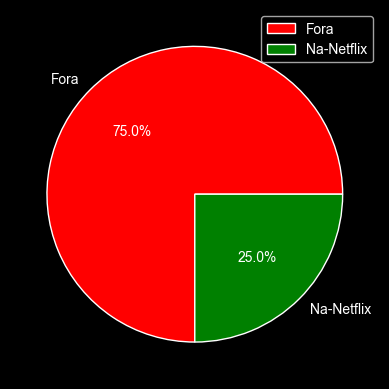

In [57]:
melhoresShows = shows.sort_values(['IMDB_Rating'], ascending=False)

showsNetflix = (melhoresShows['IMDB_Rating'] >= 9.0) & (melhoresShows['Netflix'] == 1)
dfShowsNetflix = melhoresShows.loc[showsNetflix]
qtdShowsNetflix = len(dfShowsNetflix)

showsFora = (melhoresShows['IMDB_Rating'] >= 9.0) & (melhoresShows['Netflix'] == 0)
dfShowsFora = melhoresShows.loc[showsFora]
qtdShowsForaNetflix = len(dfShowsFora)

print(f"\nA quantidade de shows na Netflix com nota acima ou igual de 9.0 : {qtdShowsNetflix}")
print(f"A quantidade de shows fora da Netflix com nota acima ou igual de 9.0 : {qtdShowsForaNetflix}")

dataShows = {
    'Status': 'Fora Na-Netflix'.split(),
    'Quantidade': [qtdShowsForaNetflix, qtdShowsNetflix],
}
dfShows = pd.DataFrame(dataShows)

color = ['#FF0000', '#008000']
dfShows.set_index('Status').plot(y='Quantidade', kind='pie', colors=color, autopct='%1.1f%%')

Resposta: Com base no Gráfico realizado, podemos observar que os shows com nota iguais ou acima de "9.0" não estão dentro do catálogo da Netflix.

---

Uma maior classificação indicativa gera series melhores avaliadas?

A média da nota dos Shows 18+ é 8.82
A média da nota dos Shows 16+ é 8.57
A média da nota dos Shows 7+ é 8.77


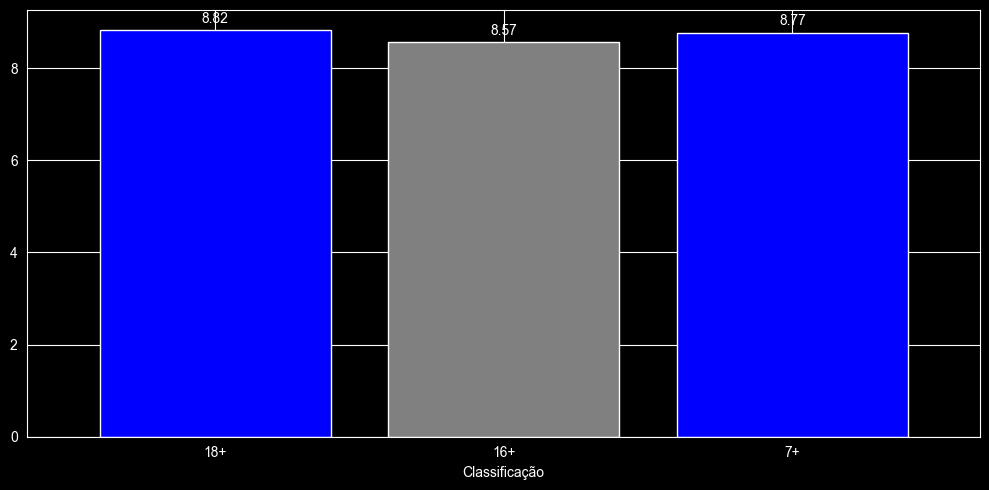

In [6]:
melhoresShows = shows.sort_values(['IMDB_Rating'], ascending=False)

showsAdultos = melhoresShows['Rating'] == '18+'
showsTeen = melhoresShows['Rating'] == '16+'
showsKids = melhoresShows['Rating'] == '7+'

dfShowsAdultos = melhoresShows.loc[showsAdultos]
dfShowsTeen = melhoresShows.loc[showsTeen]
dfShowsKids = melhoresShows.loc[showsKids]

mediaShowsAdultos = dfShowsAdultos['IMDB_Rating'].mean()
mediaShowsTeen = dfShowsTeen['IMDB_Rating'].mean()
mediaShowsKids = dfShowsKids['IMDB_Rating'].mean()

mediaShowsAdultos = round(mediaShowsAdultos, 2)
mediaShowsTeen = round(mediaShowsTeen, 2)
mediaShowsKids = round(mediaShowsKids, 2)

print(f"A média da nota dos Shows 18+ é {mediaShowsAdultos:.2f}")
print(f"A média da nota dos Shows 16+ é {mediaShowsTeen:.2f}")
print(f"A média da nota dos Shows 7+ é {mediaShowsKids:.2f}")

dataShows = {
    'Classificação': '18+ 16+ 7+'.split(),
    'Média de avaliação': [mediaShowsAdultos, mediaShowsTeen,mediaShowsKids],
}
dfShows = pd.DataFrame(dataShows)

color = ['blue', 'gray']
ax = dfShows.plot(x='Classificação', y='Média de avaliação', kind='bar', rot=0, legend=False, color=color, width=0.8,figsize=(10, 5))
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

Resposta: Considerando que a classificação de shows que estão na faixa etária de "16+", com esse gráfico pode se avaliar que uma maior classificação indicativa não sugere que terão melhores séries, pois como podemos olhar no gráfico, a classificação "7+" pois uma avaliação média maior que a de "16+", estando abaixo apenas das "18+".

---

Quais anos houveram mais lançamentos de series?

Year
2013    6
2017    4
2005    4
2019    4
2015    4
2009    4
2011    3
2016    3
2008    2
2010    2
2002    2
2014    2
2004    2
2007    2
1994    1
2001    1
1999    1
1989    1
1997    1
2006    1
Name: count, dtype: int64


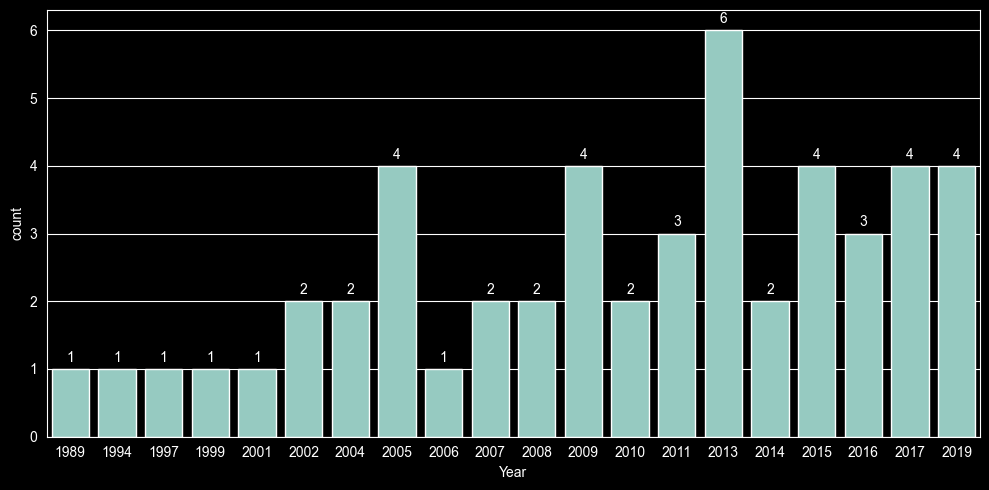

In [5]:
anosShows = shows['Year'].value_counts()
print(anosShows)

plt.figure(figsize=(10,5))
ax = sns.countplot(data=shows, x="Year")
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

Resposta: O ano que houve mais series lançadas foi o ano de 2013, com 6 lançamentos, seguidos dos anos 2017, 2005, 2019, 2015, 2009, com 4 lançamentos.

---

Quais anos lançaram as series melhores avaliadas?

                              Titles  Year Rating  IMDB_Rating  Netflix
0                       Breaking Bad  2008    18+          9.5        1
1                    Game of Thrones  2011    18+          9.3        0
2                     Rick and Morty  2013    18+          9.2        0
5         Avatar: The Last Airbender  2005     7+          9.2        1
6                           Sherlock  2010    16+          9.1        1
7                          Chernobyl  2019    18+          9.4        0
11                          The Wire  2002    18+          9.3        0
15                  Band of Brothers  2001    18+          9.4        0
22                      The Sopranos  1999    18+          9.2        0
29                    True Detective  2014    18+          9.0        0
43                           Firefly  2002    16+          9.0        0
45  Fullmetal Alchemist: Brotherhood  2009    18+          9.1        0


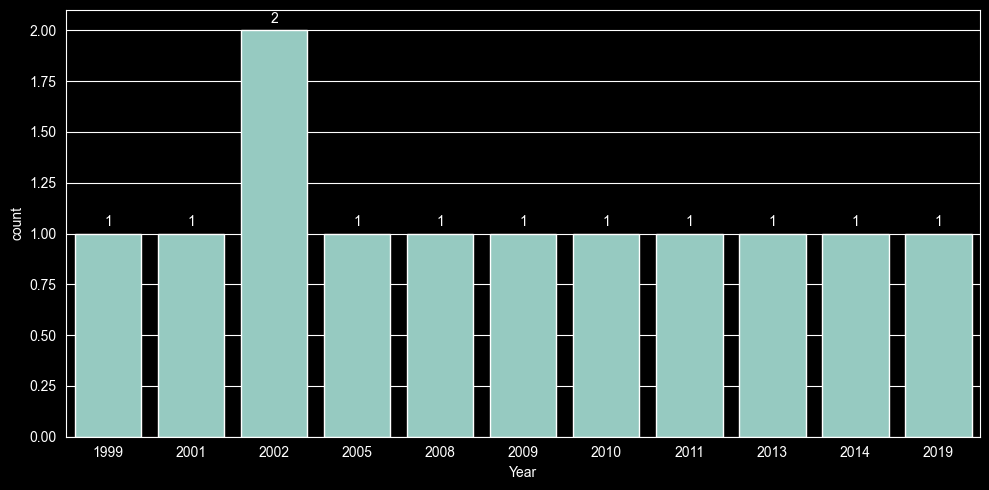

In [29]:
melhoresShows = shows['IMDB_Rating'] >= 9.0
dfMelhoresShows = shows.loc[melhoresShows]
print(dfMelhoresShows)

plt.figure(figsize=(10,5))
ax = sns.countplot(data=dfMelhoresShows, x="Year")
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

Resposta: Com base no gráfico, o ano que mais teve lançamentos que nota acima de 9.0 no IMDB foi o ano de 2002, com dois shows, o restante dos anos, ficaram empatados com 1.

---

Series novas são piores avaliadas?

A média da nota dos Shows lançados depois do ano de 2016: 8.56
A média de nota dos Shows lançados antes do ano de 2016: 8.75


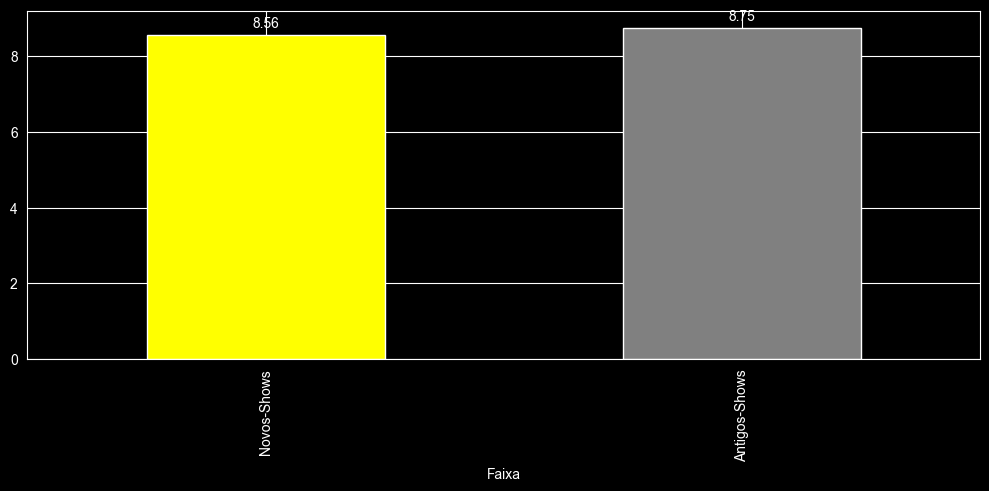

In [56]:
novosShows = shows['Year'] >= 2016
dfNovosShows = shows.loc[novosShows]

velhosShows = shows['Year'] < 2017
dfVelhosShows = shows.loc[velhosShows]

mediaNovosShows = dfNovosShows['IMDB_Rating'].mean()
mediaVelhosShows = dfVelhosShows['IMDB_Rating'].mean()

mediaNovosShows = round(mediaNovosShows, 2)
mediaVelhosShows = round(mediaVelhosShows, 2)

print(f"A média da nota dos Shows lançados depois do ano de 2016: {mediaNovosShows}")
print(f"A média de nota dos Shows lançados antes do ano de 2016: {mediaVelhosShows}")

dataShows = {
    'Faixa': 'Novos-Shows Antigos-Shows'.split(),
    'Media': [mediaNovosShows, mediaVelhosShows],
}
dfDataShows = pd.DataFrame(dataShows)

color = ['yellow', 'gray']
ax = dfDataShows.plot(x='Faixa', y='Media', color=color, legend=False, figsize=(10, 5), kind='bar')
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()


Resposta: Com base no gráfico, podemos obsersar que os Shows que foram lançados antes dos do ano de 2016, são levemente melhores avaliados em média, com a média de 8.75 em comparação com a média de 8.56 dos Shows lançados após o ano de 2016

---

Quais anos tem as series piores avaliadas?

---

Das series piores avaliadas, quantas estão na Netflix?


---

Qual classificação indicativa há em maioria na Netflix e fora?

---

Qual publico as series recentes estão buscando atualmente?

---

Qual era o publico buscado pelas series antigamente?

---